#### chair의 이미지 해상도 통알하여 적용하기

Test

In [216]:
from PIL import Image
import numpy as np

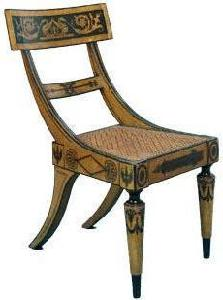

In [217]:
# chair의 1번 이미지
img = Image.open("../Data/chair/image_0001.jpg")
img

In [218]:
# 배열 크기 확인
np.array(img).shape

(300, 223, 3)

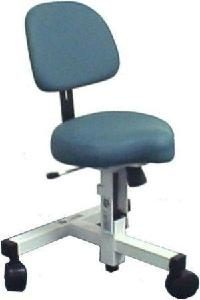

In [219]:
# chair의 2번 이미지
img2 = Image.open("../Data/chair/image_0002.jpg")
img2

> Image의 해상도가 일정하지 않음

전체 이미지의 해상도의 평균값을 가지고 적용해보자

#### Chair의 전체 이미지 평균 해상도 구하기

In [220]:
import glob

In [221]:
widthRatio = []
heightRatio = []

for file in sorted(glob.glob("../Data/chair/*.jpg")):
   img = np.array(Image.open(file), dtype=np.int32)
   widthRatio.append(img.shape[1]) # w -> 1
   heightRatio.append(img.shape[0]) # h -> 0

In [222]:
print("chair의 너비 평균 해상도:", np.mean(widthRatio))
print("chair의 높이 평균 해상도:", np.mean(heightRatio))

chair의 너비 평균 해상도: 229.65
chair의 높이 평균 해상도: 297.31666666666666


> 너비 : 264, 높이: 284로 정함

----
#### chair 이미지 해상도 및 흑백 이미지 변경

In [223]:
i = 1
for file in sorted(glob.glob("../Data/chair/*.jpg")):
   img = Image.open(file)
   imgResize = img.resize((264,284), Image.Resampling.LANCZOS)
   imgResize = imgResize.convert('L')
   imgResize.save(f"../Data/chairNew/image_{i:02}.jpg", "JPEG")
   i+=1

----
#### laptop 이미지 해상도 및 흑백 이미지 변경

In [224]:
i = 1
for file in sorted(glob.glob("../Data/laptop/*.jpg")):
   img = Image.open(file)
   imgResize = img.resize((264,284), Image.Resampling.LANCZOS)
   imgResize = imgResize.convert('L')
   imgResize.save(f"../Data/laptopNew/image_{i:02}.jpg", "JPEG")
   i+=1

----
#### chair image를 Numpy로 변경하기

In [225]:
number_of_data = 60
img_width_size = 264
img_height_size = 284

In [226]:
chairData = np.zeros(
   number_of_data * img_width_size * img_height_size,
   dtype=np.int32
).reshape(
   number_of_data,
   img_height_size,
   img_width_size
)
chairData.shape

(60, 284, 264)

In [227]:
i = 0
for file in sorted(glob.glob("../Data/chairNew/*.jpg")):
   img = np.array(Image.open(file), dtype=np.int32)
   chairData[i,:,:] = img
   i+1
chairData.shape

(60, 284, 264)

In [228]:
print(chairData[0].shape)

(284, 264)


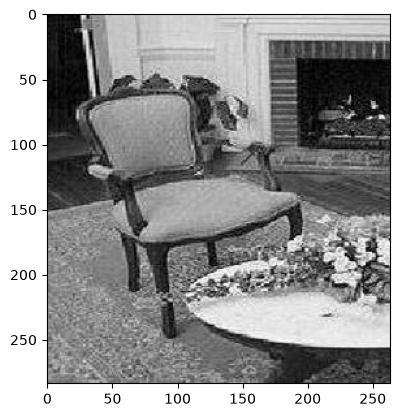

In [229]:
# 이미지 확인하기
import matplotlib.pyplot as plt

plt.imshow(chairData[0].reshape(284,264), cmap='gray')
plt.show()

#### laptop Image를 Numpy 배열로 변경하기

In [230]:
laptopData = np.zeros(
   number_of_data * img_width_size * img_height_size,
   dtype=np.int32
).reshape(
   number_of_data,
   img_height_size,
   img_width_size
)
laptopData.shape

(60, 284, 264)

In [231]:
i = 0
for file in sorted(glob.glob("../Data/laptopNew/*.jpg")):
   img = np.array(Image.open(file), dtype=np.int32)
   laptopData[i,:,:] = img
   i+1
laptopData.shape

(60, 284, 264)

In [232]:
print(laptopData[0].shape)

(284, 264)


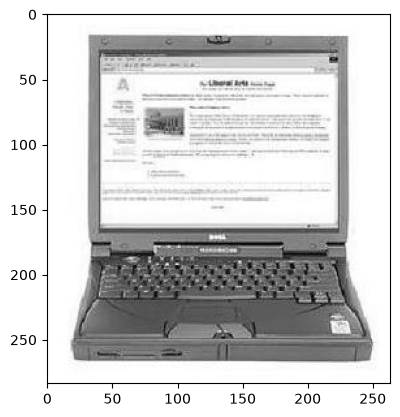

In [233]:
# 이미지 확인하기
import matplotlib.pyplot as plt

plt.imshow(laptopData[0].reshape(284,264), cmap='gray')
plt.show()

----
#### train data로 합치기


In [234]:
train = np.concatenate(
   [chairData, laptopData]
)
train.shape

(120, 284, 264)

In [235]:
target = np.concatenate(
   [np.zeros(60), np.ones(60)]
)
target.shape

(120,)

----
#### CNN으로 정확도 측정하기

- 정규화 및 채널 추가
- Train과 Test 분리
- CNN 만들기
- 시각화
- 평가(evaluate로 Train과 Test 평가)

##### 값이 이상함.

In [236]:
# 정규화 및 채널추가
train = train.reshape(-1,img_height_size,img_width_size,1) / 255.0
train.shape

(120, 284, 264, 1)

In [237]:
# Train과 Test 분리
from sklearn.model_selection import train_test_split

train_data, test_data, train_target, test_target = \
   train_test_split(
      train,
      target,
      test_size=0.2,
      random_state=42
   )

In [238]:
print(train_data.shape)
print(test_data.shape)
print(train_target.shape)
print(test_target.shape)

(96, 284, 264, 1)
(24, 284, 264, 1)
(96,)
(24,)


In [239]:
# CNN 만들기
from tensorflow import keras
from tensorflow.keras.layers import Input

In [240]:
model = keras.Sequential()
model.add (
   Input(shape=(img_height_size,img_width_size,1))
)

model.add(
   keras.layers.Conv2D(
      32,
      kernel_size=3,
      activation='relu',
      padding='same'
   )
)

model.add(
   keras.layers.MaxPool2D(2)
)

model.add(
   keras.layers.Conv2D(
      64,
      kernel_size=3,
      activation='relu',
      padding='same'
   )
)

model.add(
   keras.layers.MaxPool2D(2)
)

In [241]:
model.add(
   keras.layers.Flatten()
)

model.add(
   keras.layers.Dense(100, activation='relu')
)

model.add(
   keras.layers.Dropout(0.5)
)

model.add(
   keras.layers.Dense(80, activation='relu')
)

model.add(
   keras.layers.Dropout(0.5)
)

model.add(
   keras.layers.Dense(
      1,
      activation='sigmoid'
   )
)

In [242]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 284, 264, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 142, 132, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 142, 132, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 71, 66, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 299904)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 100)            │    29,990,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,017,477 (114.51 MB)

 Trainable params: 30,017,477 (114.51 MB)

 Non-trainable params: 0 (0.00 B)

In [243]:
model.compile(
   loss='binary_crossentropy',
   optimizer='adam',
   metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best_cnn_chair_laptop.keras")
early_stopping_cb = keras.callbacks.EarlyStopping(
   patience=7,
   restore_best_weights=True
)

In [244]:
history = model.fit(
   train_data,
   train_target,
   epochs=50, # 50
   validation_data=(test_data, test_target),
   callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.4896 - loss: 0.6913 - val_accuracy: 0.4583 - val_loss: 1.0383
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.5000 - loss: 0.6966 - val_accuracy: 0.4583 - val_loss: 1.4777
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.4896 - loss: 0.6944 - val_accuracy: 0.4583 - val_loss: 1.5690
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.5625 - loss: 0.6863 - val_accuracy: 0.4583 - val_loss: 1.5843
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.4688 - loss: 0.6882 - val_accuracy: 0.4583 - val_loss: 1.5672
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.5104 - loss: 0.6861 - val_accuracy: 0.5000 - val_loss: 1.5489
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.4688 - loss: 0.6859 - val_accuracy: 0.5000 - val_loss: 1.5350
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.5208 - loss: 0.6857 - val_accuracy: 0.5000 - val_loss: 1.5308


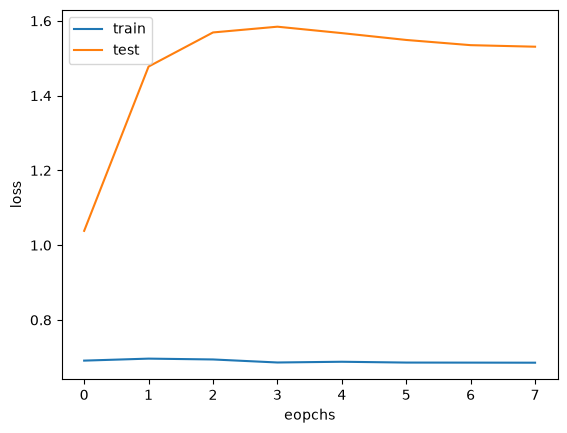

In [245]:
# 시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('eopchs')
plt.ylabel('loss')
plt.legend(['train','test'])
plt.show()

In [246]:
# 평가
model.evaluate(train_data, train_target)

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 841ms/step - accuracy: 0.5104 - loss: 0.6862


[0.6862073540687561, 0.5104166865348816]

----